# Import defect calculations

The core object of `defermi` is the `DefectsAnalysis` class, which is a list of single point defects calculations (entries). A single entry is described by the `DefectEntry` class, which contains information on the defect and the result of the calculation (energies, corrections, etc). However, this object is in practise not initialized manually. The following sections preset examples on how to import your defects datasets.

**`DataFrame`**

The most straightforward way to initialize the `DefectsAnalysis` class is by providing a `pandas.DataFrame` with the calculations result. The columns of the input `DataFrame` must be:

- `name` : Name of the defect, naming conventions described below.
- `charge` : Defect charge.
- `multiplicity` : Multiplicity in the unit cell.
- `energy_diff` : Energy of the defective cell minus the energy of the pristine cell in eV.
- `bulk_volume` : Pristine cell volume in $\mathrm{\AA^3}$

Defect naming: (element = $A$)
- `Vacancy`: `'Vac_A'` (symbol=$V_{A}$)
- `Interstitial`: `'Int_A'` (symbol=$A_{i}$)
- `Substitution`: `'Sub_B_on_A'` (symbol=$B_{A}$)
- `Polaron`: `'Pol_A'` (symbol=${A}_{A}$)
- `DefectComplex` : `'Vac_A;Int_A'` (symbol=$V_A - A_i$)

The following example shows how to create the `DataFrame` for neutral and charged $Sr$ and $O$ vacancies in $SrO$.

In [5]:
import pandas as pd

bulk_volume = 800 # cubic Amstrong

data_dict = [
{'name': 'Vac_O',
  'charge': 2,
  'multiplicity': 1,
  'energy_diff': 7,
  'bulk_volume': bulk_volume},

 {'name': 'Vac_Sr',
  'charge': -2,
  'multiplicity': 1,
  'energy_diff': 8,
  'bulk_volume': bulk_volume},

 {'name': 'Vac_O',
 'charge':0,
 'multiplicity':1,
 'energy_diff': 10.8, 
 'bulk_volume': bulk_volume},

 {'name': 'Vac_Sr',
  'charge': 0,
  'multiplicity': 1,
  'energy_diff': 7.8,
  'bulk_volume': bulk_volume},
  ]

df = pd.DataFrame(data_dict)
df

,name,charge,multiplicity,energy_diff,bulk_volume
0,Vac_O,2,1,7.0,800
1,Vac_Sr,-2,1,8.0,800
2,Vac_O,0,1,10.8,800
3,Vac_Sr,0,1,7.8,800


Now we can initialize the `DefectsAnalysis` class with the `from_dataframe` static method. We also need to provide the band gap and valence band maximum (VBM) of the pristine material.

In [9]:
from defermi import DefectsAnalysis

da = DefectsAnalysis.from_dataframe(df,band_gap=2.0,vbm=0)
da

,name,delta atoms,charge,multiplicity,corrections
0,Vac_O,{'O': -1},0,1,{}
1,Vac_O,{'O': -1},2,1,{}
2,Vac_Sr,{'Sr': -1},-2,1,{}
3,Vac_Sr,{'Sr': -1},0,1,{}


The `DefectsAnalysis` object is iterable and subscriptable like a list and contains now a collection of `DefectEntry` objects.

In [22]:
for entry in da:
    print(entry)

DefectEntry
Defect: Defect: type=Vacancy, species=O, charge=0
Energy: 10.8000
Corrections: 0.0100
Charge: 0.0
Multiplicity: 1
Data: []
Name: Vac_O


DefectEntry
Defect: Defect: type=Vacancy, species=O, charge=2
Energy: 7.0000
Corrections: 0.0000
Charge: 2.0
Multiplicity: 1
Data: []
Name: Vac_O


DefectEntry
Defect: Defect: type=Vacancy, species=Sr, charge=-2
Energy: 8.0000
Corrections: 0.0000
Charge: -2.0
Multiplicity: 1
Data: []
Name: Vac_Sr


DefectEntry
Defect: Defect: type=Vacancy, species=Sr, charge=0
Energy: 7.8000
Corrections: 0.0100
Charge: 0.0
Multiplicity: 1
Data: []
Name: Vac_Sr




All the individual information about the defect calculations are accessible through attributes of the `DefectEntry` object, as well as the functions to compute the formation energy and defect concentration

In [38]:
entry = da[1]
print(entry.defect) # Defect object
print(f"multiplicity: {entry.multiplicity}")
print(f"Difference in number of atoms btw defect and pristine: {entry.delta_atoms}")
print(f"Symbol: {entry.symbol_charge}")
print(f"Symbol in Kröger-Vink notation: {entry.symbol_kroger}")
print(f"Formation energy: {entry.formation_energy()} eV")
print(f"Defect concentration at 1000 K: {entry.defect_concentration(temperature=1000)} cm^-3")

Defect: type=Vacancy, species=O, charge=2
multiplicity: 1
Difference in number of atoms btw defect and pristine: {'O': -1}
Symbol: $V_{O}$$^{+2}$
Symbol in Kröger-Vink notation: $V_{O}$$^{°°}$
Formation energy: 7.0 eV
Defect concentration at 1000 K: 6.583589071637988e-15 cm^-3


If correction terms to the energy are present, we can add them by adding a `DataFrame` column for each. The column name must begin with `corr_`, and the string that follows will be used as label in the corrections dictionary. For example:

In [20]:
bulk_volume = 800 # cubic Amstrong
data = [
{'name': 'Vac_O','charge': 2,'multiplicity': 1,'energy_diff': 7,'bulk_volume': bulk_volume, 'corr_kumagai':0.02, 'corr_elastic':-0.02 },
{'name': 'Vac_O','charge':0,'multiplicity':1,'energy_diff': 10.8, 'bulk_volume': bulk_volume, 'corr_kumagai':0.0, 'corr_elastic':0.01},
{'name': 'Vac_Sr','charge': -2,'multiplicity': 1,'energy_diff': 8,'bulk_volume': bulk_volume, 'corr_kumagai':0.015, 'corr_elastic':-0.015 },
{'name': 'Vac_Sr','charge': 0,'multiplicity': 1,'energy_diff': 7.8,'bulk_volume': bulk_volume, 'corr_kumagai':0.0, 'corr_elastic':0.01},
]
df = pd.DataFrame(data)
df

,name,charge,multiplicity,energy_diff,bulk_volume,corr_kumagai,corr_elastic
0,Vac_O,2,1,7.0,800,0.020,-0.020
1,Vac_O,0,1,10.8,800,0.000,0.010
2,Vac_Sr,-2,1,8.0,800,0.015,-0.015
3,Vac_Sr,0,1,7.8,800,0.000,0.010


In [21]:
da = DefectsAnalysis.from_dataframe(df,band_gap=2.0,vbm=0)
da

,name,delta atoms,charge,multiplicity,corrections
0,Vac_O,{'O': -1},0,1,"{'kumagai': 0.0, 'elastic': 0.01}"
1,Vac_O,{'O': -1},2,1,"{'kumagai': 0.02, 'elastic': -0.02}"
2,Vac_Sr,{'Sr': -1},-2,1,"{'kumagai': 0.015, 'elastic': -0.015}"
3,Vac_Sr,{'Sr': -1},0,1,"{'kumagai': 0.0, 'elastic': 0.01}"


In [35]:
entry = da[1]
entry.corrections

{'kumagai': 0.02, 'elastic': -0.02}

When computing formation energies, all the correction terms in the `corrections` dictionary will be added.

The `DefectsAnalysis` object can be converted to `DataFrame` with the `to_dataframe` method, and/or stored as `csv` or `pickle` file with the `to_file` method.  

In [40]:
da.to_file('./files/DA_import_data_example.csv')
da = DefectsAnalysis.from_file('./files/DA_import_data_example.csv')
da

,name,delta atoms,charge,multiplicity,corrections
0,Vac_O,{'O': -1},0,1,"{'kumagai': 0.0, 'elastic': 0.01}"
1,Vac_O,{'O': -1},2,1,"{'kumagai': 0.02, 'elastic': -0.02}"
2,Vac_Sr,{'Sr': -1},-2,1,"{'kumagai': 0.015, 'elastic': -0.015}"
3,Vac_Sr,{'Sr': -1},0,1,"{'kumagai': 0.0, 'elastic': 0.01}"


**VASP**

Defect calculations can also be imported directly from VASP directories with the `from_vasp_directories` static method. With this approach, the individual `Defect` objects will store the structural data as well, like the defective structure and position of the defect. Charge corrections (FNV or eFNV) can be performed automatically using the `pymatgen-analysis-defects` package. The multiplicity in the unit cell can be automatically determined for `Substitution` or `Vacancy` defects, it is not yet implemented for `Interstitial` and `DefectComplex`.

Here is an example where we initialize the `DefectsAnalysis` object from directories with VASP calculations, using the `defermi` test files for defects in $\mathrm{SiO_2}$.

importing from ../defermi/tests/test_files/SiO2-defects/Defects/complexes/Vac_Si-Vac_O/q-1/2-PBE-OPT
Defect automatically identified for defective structure with composition Si23 O47: 
 DefectComplex: [ Defect: type=Vacancy, species=Si, site= [0.26554429 0.26554429 0.5       ], Defect: type=Vacancy, species=O, site= [0.13461155 0.20669714 0.89244549], ] 


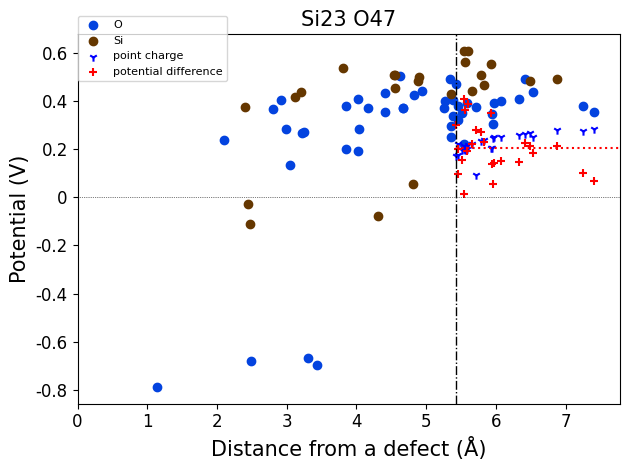

importing from ../defermi/tests/test_files/SiO2-defects/Defects/complexes/Vac_Si-Vac_O/q-2/2-PBE-OPT
Defect automatically identified for defective structure with composition Si23 O47: 
 DefectComplex: [ Defect: type=Vacancy, species=Si, site= [0.26554429 0.26554429 0.5       ], Defect: type=Vacancy, species=O, site= [0.13461155 0.20669714 0.89244549], ] 


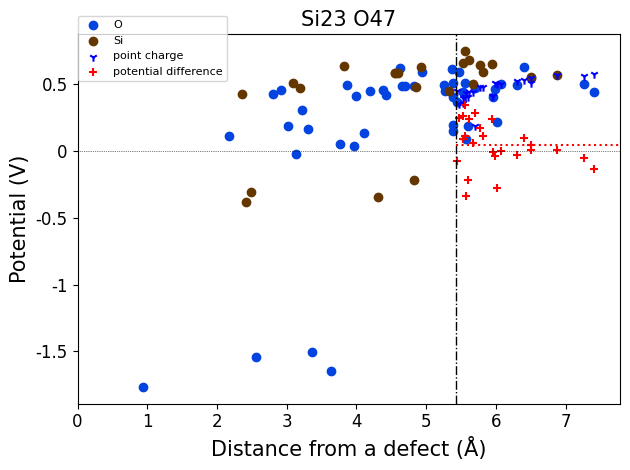

importing from ../defermi/tests/test_files/SiO2-defects/Defects/complexes/Vac_Si-Vac_O/q-3/2-PBE-OPT
Defect automatically identified for defective structure with composition Si23 O47: 
 DefectComplex: [ Defect: type=Vacancy, species=Si, site= [0.26554429 0.26554429 0.5       ], Defect: type=Vacancy, species=O, site= [0.13461155 0.20669714 0.89244549], ] 


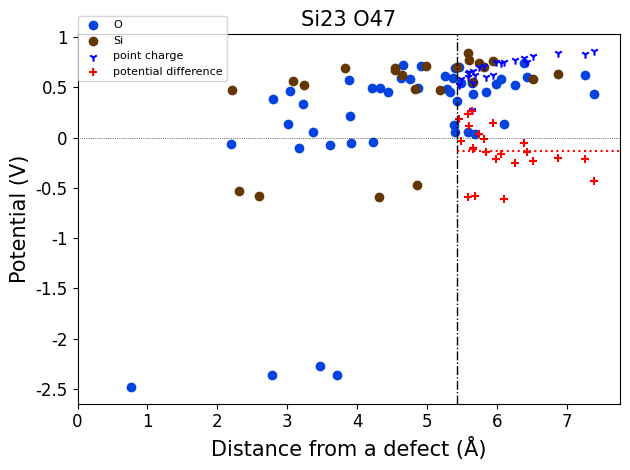

importing from ../defermi/tests/test_files/SiO2-defects/Defects/interstitials/Int_O_mult24/q-1/2-PBE-OPT
Defect automatically identified for defective structure with composition Si24 O49: 
 Defect: type=Interstitial, species=O, site= [0.5        0.69683435 0.08333333]


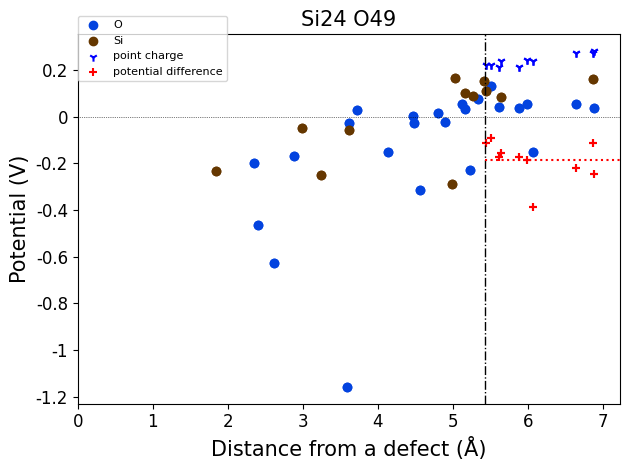

importing from ../defermi/tests/test_files/SiO2-defects/Defects/interstitials/Int_O_mult24/q-2/2-PBE-OPT
Defect automatically identified for defective structure with composition Si24 O49: 
 Defect: type=Interstitial, species=O, site= [0.5        0.69683435 0.08333333]


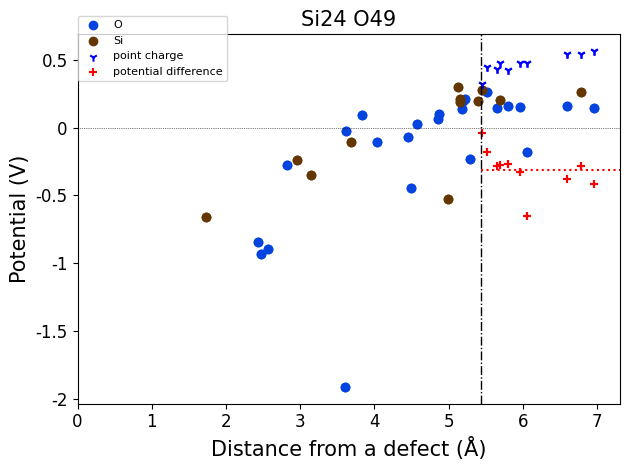

importing from ../defermi/tests/test_files/SiO2-defects/Defects/interstitials/Int_O_mult24/q0/2-PBE-OPT
Defect automatically identified for defective structure with composition Si24 O49: 
 Defect: type=Interstitial, species=O, site= [0.5        0.69683435 0.08333333]


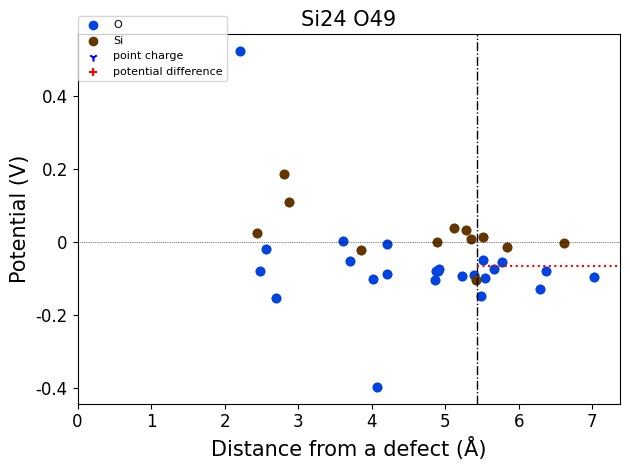

importing from ../defermi/tests/test_files/SiO2-defects/Defects/substitutions/Sub_P_on_Si/q0/2-PBE-OPT
Defect automatically identified for defective structure with composition Si23 P1 O48: 
 Defect: type=Substitution, species=P, site= [0.26554429 0.26554429 0.        ]


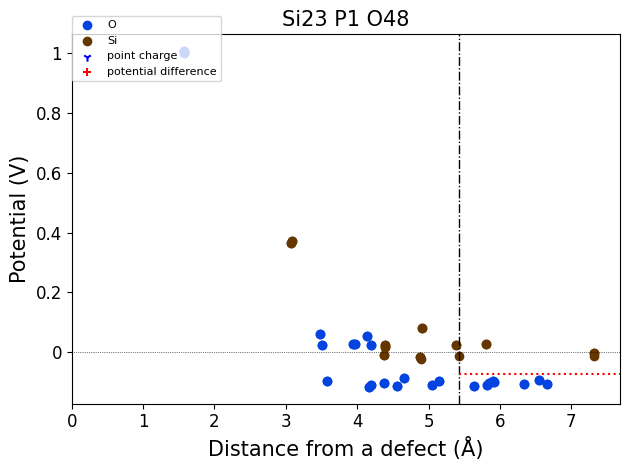

importing from ../defermi/tests/test_files/SiO2-defects/Defects/substitutions/Sub_P_on_Si/q1/2-PBE-OPT
Defect automatically identified for defective structure with composition Si23 P1 O48: 
 Defect: type=Substitution, species=P, site= [0.26554429 0.26554429 0.        ]


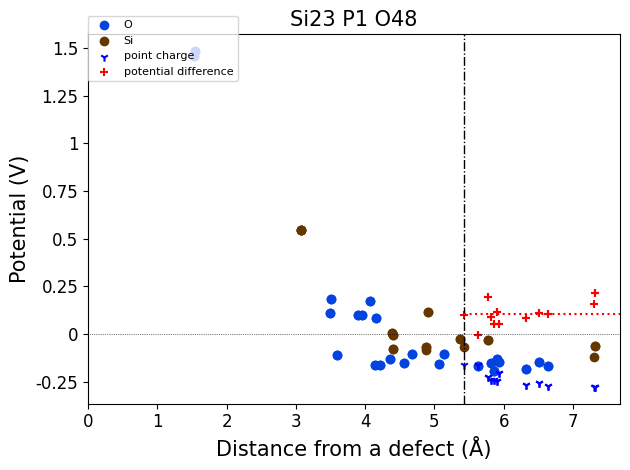

importing from ../defermi/tests/test_files/SiO2-defects/Defects/vacancies/Vac_O/q0/2-PBE-OPT
Defect automatically identified for defective structure with composition Si24 O47: 
 Defect: type=Vacancy, species=O, site= [0.13461155 0.20669714 0.39244549]


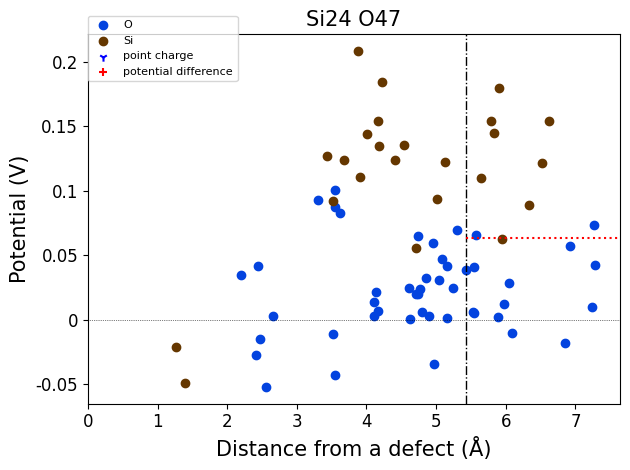

importing from ../defermi/tests/test_files/SiO2-defects/Defects/vacancies/Vac_O/q1/2-PBE-OPT
Defect automatically identified for defective structure with composition Si24 O47: 
 Defect: type=Vacancy, species=O, site= [0.13461155 0.20669714 0.39244549]


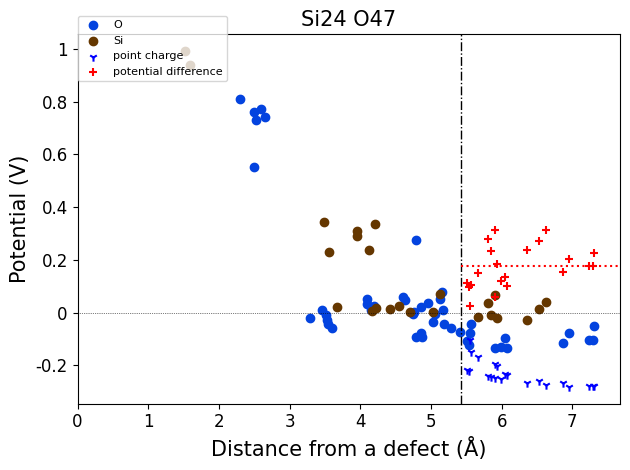

importing from ../defermi/tests/test_files/SiO2-defects/Defects/vacancies/Vac_O/q2/2-PBE-OPT
Defect automatically identified for defective structure with composition Si24 O47: 
 Defect: type=Vacancy, species=O, site= [0.13461155 0.20669714 0.39244549]


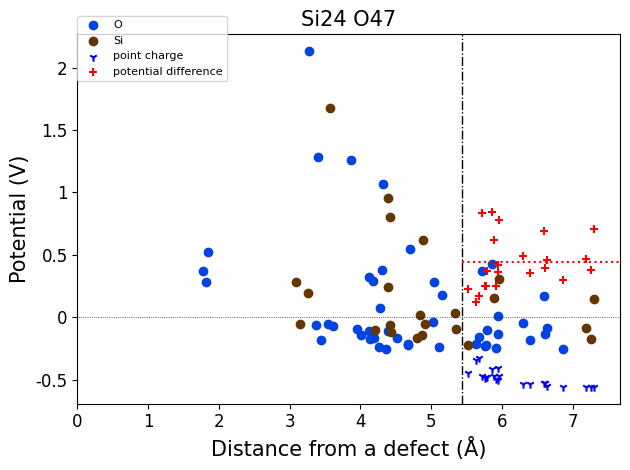

importing from ../defermi/tests/test_files/SiO2-defects/Defects/vacancies/Vac_Si/q-3/2-PBE-OPT
Defect automatically identified for defective structure with composition Si23 O48: 
 Defect: type=Vacancy, species=Si, site= [0.26554429 0.26554429 0.        ]


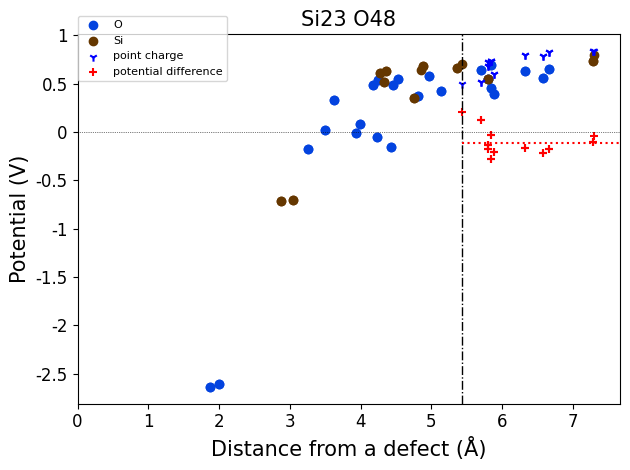

importing from ../defermi/tests/test_files/SiO2-defects/Defects/vacancies/Vac_Si/q-4/2-PBE-OPT
Defect automatically identified for defective structure with composition Si23 O48: 
 Defect: type=Vacancy, species=Si, site= [0.26554429 0.26554429 0.        ]


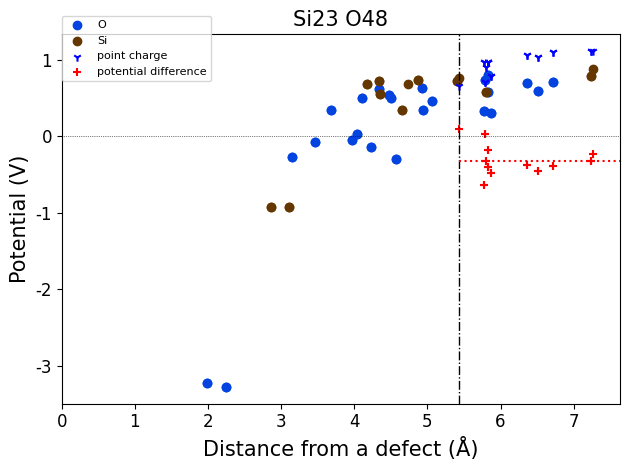

importing from ../defermi/tests/test_files/SiO2-defects/Defects/vacancies/Vac_Si/q-5/2-PBE-OPT
Defect automatically identified for defective structure with composition Si23 O48: 
 Defect: type=Vacancy, species=Si, site= [0.26554429 0.26554429 0.        ]


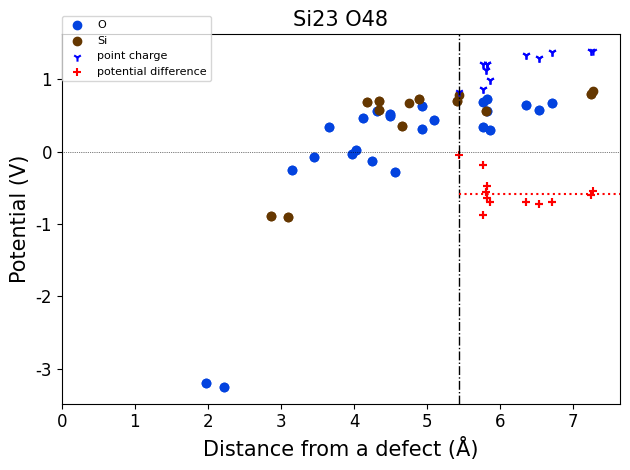

In [41]:
from defermi import DefectsAnalysis

dielectric_constant = 3.9

path_defects = '../defermi/tests/test_files/SiO2-defects/Defects'
path_bulk = '../defermi/tests/test_files/SiO2-defects/Bulk-2x2x2-supercell'

da_vasp = DefectsAnalysis.from_vasp_directories(
                                path_defects=path_defects,
                                path_bulk=path_bulk,
                                common_path='2-PBE-OPT',
                                get_charge_correction='kumagai',
                                dielectric_tensor=dielectric_constant,
                                get_multiplicity=True,
                                initial_structure=True)

In [3]:
da_vasp

,name,delta atoms,charge,multiplicity,corrections
0,Int_O,{'O': 1},-2.0,1,{'kumagai': 1.5376721136614186}
1,Int_O,{'O': 1},-1.0,1,{'kumagai': 0.35416500246128524}
2,Int_O,{'O': 1},0.0,1,{'kumagai': 0.0}
3,Sub_P_on_Si,"{'P': 1, 'Si': -1}",0.0,24,{'kumagai': 0.0}
4,Sub_P_on_Si,"{'P': 1, 'Si': -1}",1.0,24,{'kumagai': 0.4363501100303799}
5,Vac_O,{'O': -1},0.0,48,{'kumagai': 0.0}
6,Vac_O,{'O': -1},1.0,48,{'kumagai': 0.36412325454690586}
7,Vac_O,{'O': -1},2.0,48,{'kumagai': 1.271380937175993}
8,Vac_Si,{'Si': -1},-5.0,24,{'kumagai': 10.56056661808925}
9,Vac_Si,{'Si': -1},-4.0,24,{'kumagai': 7.3293307242822925}


Because the data was imported from VASP calculations, each entry will now contain structure data. When saving the object to a file, also the structures can be stored if the export format is `pkl` or `json`.

In [43]:
entry = da_vasp[0]
entry.defect.site

PeriodicSite: O (5.882, 1.676, 0.9052) [0.5, 0.6968, 0.08333]

In [48]:
da_vasp.to_file('./files/DA_import_data_vasp.pkl')
DefectsAnalysis.from_file('./files/DA_import_data_vasp.pkl')

,name,delta atoms,charge,multiplicity,corrections
0,Int_O,{'O': 1},-2.0,1,{'kumagai': 1.5376721136614186}
1,Int_O,{'O': 1},-1.0,1,{'kumagai': 0.35416500246128524}
2,Int_O,{'O': 1},0.0,1,{'kumagai': 0.0}
3,Sub_P_on_Si,"{'P': 1, 'Si': -1}",0.0,24,{'kumagai': 0.0}
4,Sub_P_on_Si,"{'P': 1, 'Si': -1}",1.0,24,{'kumagai': 0.4363501100303799}
5,Vac_O,{'O': -1},0.0,48,{'kumagai': 0.0}
6,Vac_O,{'O': -1},1.0,48,{'kumagai': 0.36412325454690586}
7,Vac_O,{'O': -1},2.0,48,{'kumagai': 1.271380937175993}
8,Vac_Si,{'Si': -1},-5.0,24,{'kumagai': 10.56056661808925}
9,Vac_Si,{'Si': -1},-4.0,24,{'kumagai': 7.3293307242822925}
